In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

mean filter / averaging filter

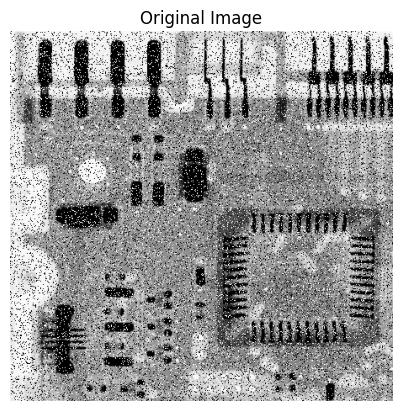

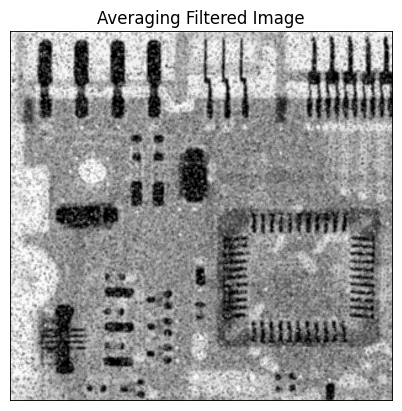

In [ ]:
# read the image in grayscale mode
img = cv2.imread('inputimage.png', 0) # 0 means the image will be loaded as black and white

# get the image dimensions
# m = number of rows(height)
# n = number of columns(width)
m, n = img.shape

# create a 3x3 matrix filled with is
mask = np.ones([3, 3], dtype=int)

# devide each value by 9
# this is called an average filtering (blur filter)
mask = mask / 9

# create a new image of same size filled with zeros
# this will store the blurred result
img_new = np.zeros([m, n])

# loop through each pixel (skip borders to avoid errors)
for i in range(1, m-1):
  for j in range(1, n-1):

    # multiply the each neighboring pixel with mask
    # and add them together (this is convolution)
    temp = (
        img[i-1, j-1] * mask[0, 0] + # top-left
        img[i-1, j]   * mask[0, 1] + # top
        img[i-1, j+1] * mask[0, 2] + # top-right

        img[i, j-1]   * mask[1, 0] + # left
        img[i, j]     * mask[1, 1] + # center
        img[i, j+1]   * mask[1, 2] + # right

        img[i+1, j-1] * mask[2, 0] + # bottom-left
        img[i+1, j]   * mask[2, 1] + # bottom
        img[i+1, j+1] * mask[2, 2]   # bottom-right
    )

    # store the new computed value in the new image
    img_new[i, j] = temp

  # convert value to unsigned 8-bits integers
  # this is required for displaying / saving images properly
  img_new = img_new.astype(np.uint8)

  # save the output image
  cv2.imwrite('Averaging Filtered Image.tif', img_new)

# display the original image using matplotlib
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# display the blurred image using matplotlin
plt.imshow(img_new, cmap='gray')
plt.title('Averaging Filtered Image')
plt.axis('off')
plt.show()

gaussian filter

(np.float64(-0.5), np.float64(599.5), np.float64(799.5), np.float64(-0.5))

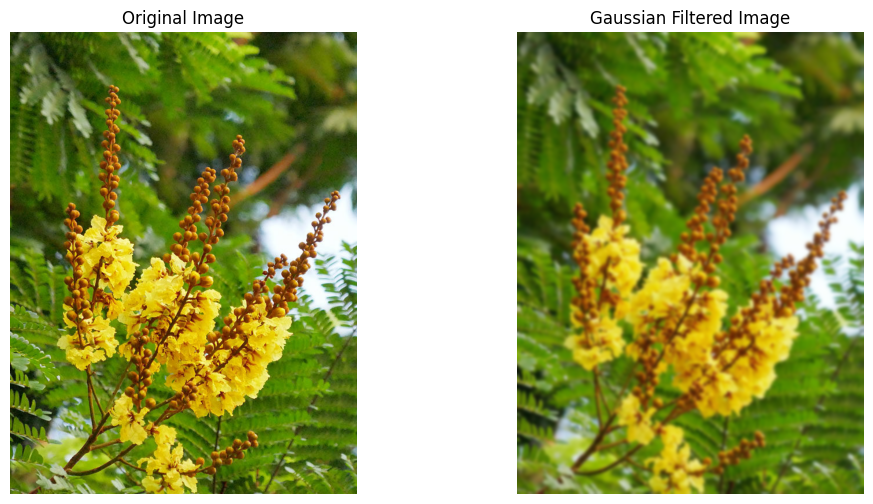

In [ ]:
# load the image
image = cv2.imread('PEL-PTE-s5-4-600x800.jpg', cv2.IMREAD_COLOR)

# convert from BGR to RGB for correct color display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# apply gaussian filter
kernel_size = (15, 15)
sigma_value = 0 # sigma define the blur strength, 0 means that openCV  will automatically calculate the optimal value for
gaussian_blur = cv2.GaussianBlur(image_rgb, kernel_size, sigma_value)

# create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# display the original image
axes[0].imshow(image_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

# display the gaussian filter image
axes[1].imshow(gaussian_blur)
axes[1].set_title('Gaussian Filtered Image')
axes[1].axis('off')

laplacian filter

(np.float64(-0.5), np.float64(599.5), np.float64(799.5), np.float64(-0.5))

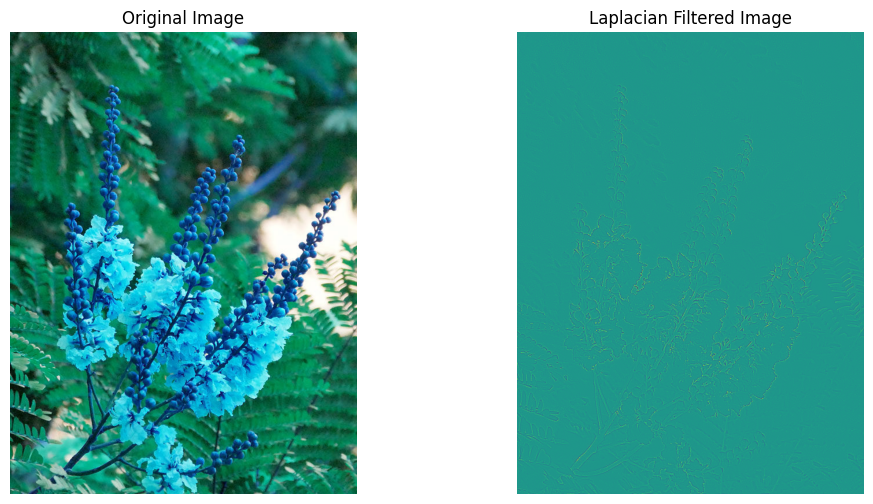

In [ ]:
# load the image
image = cv2.imread('PEL-PTE-s5-4-600x800.jpg', cv2.IMREAD_COLOR)

# convert from BGR to RGB for correct color display
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# apply laplacian filter
laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)

# create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# display the original image
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

# display the gaussian filter image
axes[1].imshow(laplacian)
axes[1].set_title('Laplacian Filtered Image')
axes[1].axis('off')

smoothing filter (non-linear filter)

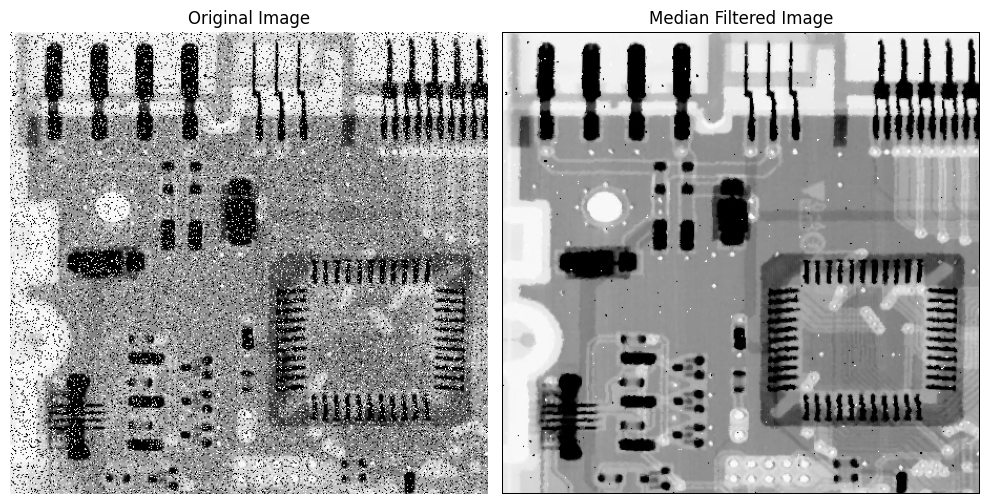

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image in grayscale mode
# 0 means grayscale image
image_noisy1 = cv2.imread('inputimage.png', 0)

# Check whether the image is loaded correctly
if image_noisy1 is None:
    print("Error: Image not found!")
    exit()

# Get image dimensions
m, n = image_noisy1.shape

# Create an empty image for output
img_new1 = np.zeros((m, n), dtype=np.uint8)

# Apply Median Filter
for i in range(1, m - 1):
    for j in range(1, n - 1):

        # Extract 3x3 neighboring pixels
        temp = [
            image_noisy1[i - 1, j - 1],
            image_noisy1[i - 1, j],
            image_noisy1[i - 1, j + 1],
            image_noisy1[i, j - 1],
            image_noisy1[i, j],
            image_noisy1[i, j + 1],
            image_noisy1[i + 1, j - 1],
            image_noisy1[i + 1, j],
            image_noisy1[i + 1, j + 1]
        ]

        # Sort the pixel values
        temp.sort()

        # Assign the median value
        img_new1[i, j] = temp[4]

# Save the filtered image
cv2.imwrite('new_median_filter_image.png', img_new1)

# Display Original Image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_noisy1, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Display Median Filtered Image
plt.subplot(1, 2, 2)
plt.imshow(img_new1, cmap='gray')
plt.title('Median Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()